In [1]:
# ============================================================
# NOTEBOOK 07: SCORECARD CON WoE
# Proyecto: Credit Risk Scoring ML
# Autor: Marín Serrato Barrios
# Descripción: Implementación de scorecard crediticio con
#              Weight of Evidence (WoE) y conversión a puntos.
#              Complementa el modelo LightGBM del notebook 03.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from optbinning import BinningProcess
from optbinning import Scorecard
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

# Configuración
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

import os
RUTA_PROYECTO = "c:/Users/Marin/Documents/PROYECTO ML_OPS/credit-risk-scoring-ml"
os.chdir(RUTA_PROYECTO)

print(f"Directorio: {os.getcwd()}")
print(f"\n✅ Librerías importadas correctamente")
print(f"   optbinning: {__import__('optbinning').__version__}")

Directorio: c:\Users\Marin\Documents\PROYECTO ML_OPS\credit-risk-scoring-ml

✅ Librerías importadas correctamente
   optbinning: 0.21.0


In [2]:
# ─────────────────────────────────────────────
# CARGAR DATOS
# Usamos df_lgbm que tiene las features engineeradas
# del notebook 02 — incluyendo EXT_SOURCE_PROMEDIO,
# PLAZO_MESES, DTI_RATIO y demás variables derivadas
# ─────────────────────────────────────────────

print("Cargando datos...")
df = pd.read_csv("data/processed/df_lgbm.csv")

print(f"Shape: {df.shape}")
print(f"Tasa de mora: {df['TARGET'].mean():.2%}")
print(f"Features disponibles: {df.shape[1] - 2}")  # -TARGET -SK_ID_CURR

# Separar features y target
TARGET = "TARGET"
EXCLUIR = ["TARGET", "SK_ID_CURR"]
features = [c for c in df.columns if c not in EXCLUIR]

X = df[features]
y = df[TARGET]

# Split estratificado 70/30
# Estratificado = mantiene proporción de mora en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"\nTrain: {X_train.shape[0]:,} registros | mora: {y_train.mean():.2%}")
print(f"Test:  {X_test.shape[0]:,} registros  | mora: {y_test.mean():.2%}")
print(f"\n✅ Datos listos para WoE")

Cargando datos...
Shape: (307511, 67)
Tasa de mora: 8.07%
Features disponibles: 65

Train: 215,257 registros | mora: 8.07%
Test:  92,254 registros  | mora: 8.07%

✅ Datos listos para WoE


In [3]:
# ─────────────────────────────────────────────
# SELECCIÓN DE VARIABLES Y CÁLCULO DE WoE/IV
# optbinning calcula automáticamente el binning
# óptimo y los valores WoE para cada variable
# ─────────────────────────────────────────────

# Variables seleccionadas para el scorecard
# Basadas en importancia SHAP del notebook 03
# y conocimiento del dominio crediticio
VARIABLES_SCORECARD = [
    "EXT_SOURCE_PROMEDIO",    # Score externo combinado — más importante
    "EXT_SOURCE_2",           # Score externo Buró fuente 2
    "EXT_SOURCE_3",           # Score externo Buró fuente 3
    "PLAZO_MESES",            # Plazo del crédito en meses
    "AMT_GOODS_PRICE",        # Precio del bien a financiar
    "AMT_INCOME_TOTAL",       # Ingreso anual del solicitante
    "DAYS_EMPLOYED",          # Antigüedad laboral (negativo = años empleado)
    "DAYS_BIRTH",             # Edad (negativo = días desde nacimiento)
    "AMT_CREDIT",             # Monto del crédito solicitado
    "RIESGO_EDAD_SCORE",      # Score combinado riesgo/edad
    "ANNUITY_INCOME_PERC",    # Proporción pago mensual / ingreso
    "INCOME_CREDIT_PERC",     # Proporción ingreso / crédito
]

# Verificar que todas las variables existen en el dataset
variables_ok = [v for v in VARIABLES_SCORECARD if v in X_train.columns]
variables_faltantes = [v for v in VARIABLES_SCORECARD if v not in X_train.columns]

if variables_faltantes:
    print(f"⚠️ Variables no encontradas: {variables_faltantes}")

print(f"Variables para scorecard: {len(variables_ok)}")
print()

# Configurar el proceso de binning
# BinningProcess encuentra automáticamente los mejores
# puntos de corte para cada variable maximizando IV
binning_process = BinningProcess(
    variable_names=variables_ok,
    # max_n_bins: máximo de rangos por variable
    # más rangos = más granularidad pero riesgo de overfitting
    max_n_bins=6,
    # min_bin_size: mínimo de registros por rango
    # evita rangos con muy pocos casos (inestables)
    min_bin_size=0.05
)

print("Calculando WoE e IV para cada variable...")
binning_process.fit(X_train[variables_ok], y_train)
print("✅ Binning completado")

# Obtener resumen de IV por variable
resumen_iv = binning_process.summary()
resumen_iv = resumen_iv.sort_values("iv", ascending=False)

print(f"\n{'Variable':<30} {'IV':>8}  {'Poder predictivo'}")
print("─" * 60)
for _, row in resumen_iv.iterrows():
    iv = row['iv']
    if iv < 0.02:
        poder = "❌ Sin poder — descartar"
    elif iv < 0.10:
        poder = "⚠️ Débil"
    elif iv < 0.30:
        poder = "✅ Moderado"
    elif iv < 0.50:
        poder = "✅ Fuerte"
    else:
        poder = "⚠️ Muy alto — revisar leakage"
    print(f"{row['name']:<30} {iv:>8.4f}  {poder}")

⚠️ Variables no encontradas: ['ANNUITY_INCOME_PERC', 'INCOME_CREDIT_PERC']
Variables para scorecard: 10

Calculando WoE e IV para cada variable...
✅ Binning completado

Variable                             IV  Poder predictivo
────────────────────────────────────────────────────────────
EXT_SOURCE_PROMEDIO              0.6112  ⚠️ Muy alto — revisar leakage
RIESGO_EDAD_SCORE                0.3430  ✅ Fuerte
EXT_SOURCE_3                     0.3293  ✅ Fuerte
EXT_SOURCE_2                     0.3143  ✅ Fuerte
DAYS_EMPLOYED                    0.1143  ✅ Moderado
AMT_GOODS_PRICE                  0.0885  ⚠️ Débil
DAYS_BIRTH                       0.0879  ⚠️ Débil
AMT_CREDIT                       0.0558  ⚠️ Débil
PLAZO_MESES                      0.0271  ⚠️ Débil
AMT_INCOME_TOTAL                 0.0126  ❌ Sin poder — descartar


In [5]:
# ─────────────────────────────────────────────
# ENTRENAR EL SCORECARD
# Solo usamos variables con IV >= 0.05
# ─────────────────────────────────────────────

# Filtrar variables con poder predictivo suficiente
UMBRAL_IV = 0.05
variables_finales = resumen_iv[resumen_iv['iv'] >= UMBRAL_IV]['name'].tolist()

print(f"Variables seleccionadas (IV >= {UMBRAL_IV}):")
for v in variables_finales:
    iv = resumen_iv[resumen_iv['name']==v]['iv'].values[0]
    print(f"  {v:<30} IV={iv:.4f}")

print(f"\nTotal variables en scorecard: {len(variables_finales)}")

# Reconfigurar binning solo con variables finales
binning_process_final = BinningProcess(
    variable_names=variables_finales,
    max_n_bins=6,
    min_bin_size=0.05
)

# Configurar Regresión Logística
# C=1.0: regularización estándar
# max_iter=1000: suficientes iteraciones para convergencia
lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

# Construir scorecard
# scaling_method='pdo-odds': escala PDO estándar de industria
# scaling_method_params: PDO=20, score base=600, odds base=50:1
scorecard = Scorecard(
    binning_process=binning_process_final,
    estimator=lr,
    scaling_method="pdo_odds",
    scaling_method_params={
        "pdo": 20,
        # PDO = Points to Double the Odds
        # Cada 20 puntos, el riesgo se duplica
        "odds": 50,
        # En score_base, hay 50 buenos por cada malo
        "scorecard_points": 600
        # Score base = 600 puntos
    },
    intercept_based=True
    # intercept_based: el intercepto tiene su propio
    # puntaje en la tabla de puntos — más transparente
)

print("\nEntrenando scorecard...")
scorecard.fit(X_train[variables_finales], y_train)
print("✅ Scorecard entrenado")

Variables seleccionadas (IV >= 0.05):
  EXT_SOURCE_PROMEDIO            IV=0.6112
  RIESGO_EDAD_SCORE              IV=0.3430
  EXT_SOURCE_3                   IV=0.3293
  EXT_SOURCE_2                   IV=0.3143
  DAYS_EMPLOYED                  IV=0.1143
  AMT_GOODS_PRICE                IV=0.0885
  DAYS_BIRTH                     IV=0.0879
  AMT_CREDIT                     IV=0.0558

Total variables en scorecard: 8

Entrenando scorecard...
✅ Scorecard entrenado


In [6]:
# ─────────────────────────────────────────────
# EVALUACIÓN DEL SCORECARD
# ─────────────────────────────────────────────

# Predicciones
scores_train = scorecard.score(X_train[variables_finales])
scores_test  = scorecard.score(X_test[variables_finales])

proba_train = scorecard.predict_proba(X_train[variables_finales])[:, 1]
proba_test  = scorecard.predict_proba(X_test[variables_finales])[:, 1]

# Métricas
auc_train = roc_auc_score(y_train, proba_train)
auc_test  = roc_auc_score(y_test, proba_test)

from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, proba_test)
ks_test = max(tpr - fpr)

print("=" * 50)
print("MÉTRICAS DEL SCORECARD CON WoE")
print("=" * 50)
print(f"AUC Train:  {auc_train:.4f}")
print(f"AUC Test:   {auc_test:.4f}")
print(f"Brecha:     {auc_train - auc_test:.4f}  "
      f"({'✅ Sin overfitting' if auc_train - auc_test < 0.02 else '⚠️ Revisar overfitting'})")
print(f"KS Test:    {ks_test:.4f}")
print(f"Gini Test:  {2*auc_test-1:.4f}")
print()
print(f"Score mínimo: {scores_test.min():.0f} pts")
print(f"Score máximo: {scores_test.max():.0f} pts")
print(f"Score media:  {scores_test.mean():.0f} pts")
print()

# Comparación con LightGBM del notebook 03
print("COMPARACIÓN CON LIGHTGBM:")
print(f"{'Métrica':<15} {'Scorecard WoE':>15} {'LightGBM':>15}")
print("─" * 45)
print(f"{'AUC Test':<15} {auc_test:>15.4f} {'0.7681':>15}")
print(f"{'KS Test':<15} {ks_test:>15.4f} {'0.4017':>15}")
print(f"{'Gini Test':<15} {2*auc_test-1:>15.4f} {'0.5363':>15}")


MÉTRICAS DEL SCORECARD CON WoE
AUC Train:  0.7298
AUC Test:   0.7280
Brecha:     0.0018  (✅ Sin overfitting)
KS Test:    0.3402
Gini Test:  0.4560

Score mínimo: 489 pts
Score máximo: 627 pts
Score media:  566 pts

COMPARACIÓN CON LIGHTGBM:
Métrica           Scorecard WoE        LightGBM
─────────────────────────────────────────────
AUC Test                 0.7280          0.7681
KS Test                  0.3402          0.4017
Gini Test                0.4560          0.5363


In [7]:
# ─────────────────────────────────────────────
# TABLA DE PUNTOS POR VARIABLE
# Esta es la "tarjeta de puntaje" — muestra
# exactamente cuántos puntos aporta cada rango
# de cada variable. Es lo que la CNBV puede auditar.
# ─────────────────────────────────────────────

print("=" * 70)
print("TABLA DE PUNTOS DEL SCORECARD")
print("Mayor puntaje = menor riesgo")
print("=" * 70)

tabla_puntos = scorecard.table(style="detailed")

# Mostrar por variable
for variable in variables_finales:
    subtabla = tabla_puntos[tabla_puntos['Variable'] == variable]
    if len(subtabla) == 0:
        continue

    iv_var = resumen_iv[resumen_iv['name']==variable]['iv'].values[0]
    print(f"\n📊 {variable}  (IV={iv_var:.4f})")
    print(f"   {'Rango':<35} {'Puntos':>8}  {'% Buenos':>10}  {'% Malos':>10}")
    print(f"   {'─'*35} {'─'*8}  {'─'*10}  {'─'*10}")

    for _, row in subtabla.iterrows():
        puntos = row.get('Points', row.get('Score', 0))
        buenos = row.get('Event rate', 0)
        print(f"   {str(row['Bin']):<35} {puntos:>8.1f}  {buenos:>10.2%}")

TABLA DE PUNTOS DEL SCORECARD
Mayor puntaje = menor riesgo

📊 EXT_SOURCE_PROMEDIO  (IV=0.6112)
   Rango                                 Puntos    % Buenos     % Malos
   ─────────────────────────────────── ────────  ──────────  ──────────
   (-inf, 0.24)                             0.0      26.56%
   [0.24, 0.37)                             9.2      16.32%
   [0.37, 0.47)                            17.9       9.80%
   [0.47, 0.56)                            25.4       6.16%
   [0.56, 0.68)                            33.4       3.70%
   [0.68, inf)                             42.6       2.03%
   Special                                 21.1       0.00%
   Missing                                 21.1       9.84%

📊 RIESGO_EDAD_SCORE  (IV=0.3430)
   Rango                                 Puntos    % Buenos     % Malos
   ─────────────────────────────────── ────────  ──────────  ──────────
   (-inf, 0.13)                             4.2       3.86%
   [0.13, 0.23)                            

CRITERIOS DE DECISIÓN RECOMENDADOS

Distribución de scores (test set):
  Percentil 25: 549 pts
  Percentil 50: 568 pts
  Percentil 75: 584 pts

Bandas de riesgo:
Banda               Umbral        N   %Cartera    %Mora
───────────────────────────────────────────────────────
✅ APROBAR           >= 570   43,676      47.3%     3.3%
⚠️ REVISAR         545-570   29,684      32.2%     8.1%
❌ RECHAZAR           < 545   18,894      20.5%    19.0%

Gráfica guardada: reports/12_scorecard_distribucion.png


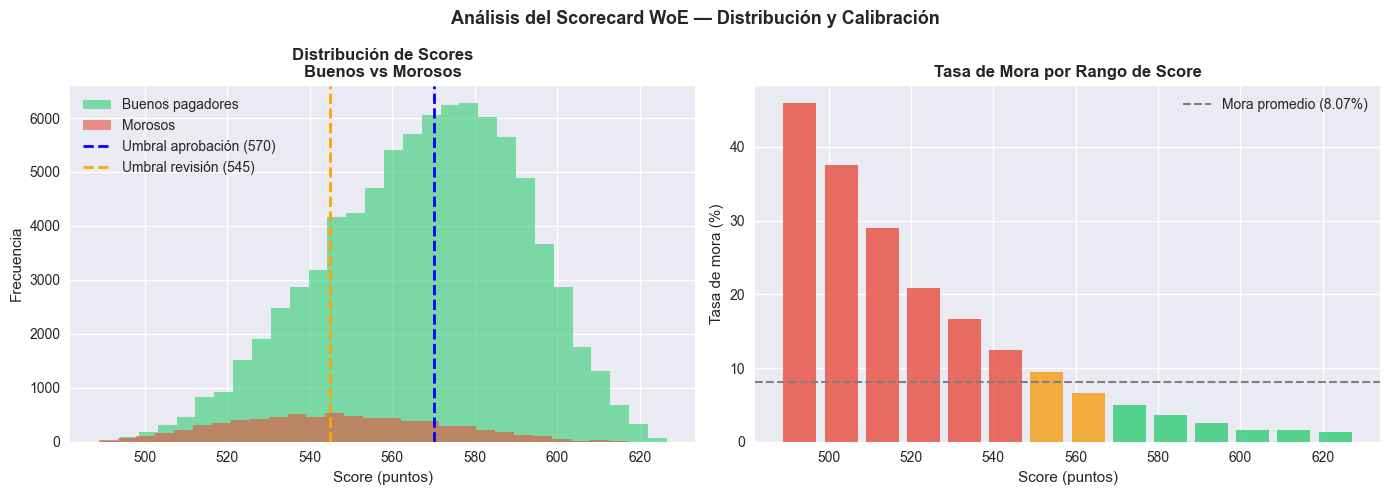

In [9]:
# ─────────────────────────────────────────────
# CRITERIOS DE DECISIÓN Y DISTRIBUCIÓN DE SCORES
# ─────────────────────────────────────────────

# Calcular scores para todo el test set
scores_test_df = pd.DataFrame({
    'score': scores_test,
    'target': y_test.values
})

# Definir bandas de riesgo basadas en la distribución
# Los umbrales se calibran según el apetito de riesgo
p25 = np.percentile(scores_test, 25)
p50 = np.percentile(scores_test, 50)
p75 = np.percentile(scores_test, 75)

print("=" * 50)
print("CRITERIOS DE DECISIÓN RECOMENDADOS")
print("=" * 50)
print(f"\nDistribución de scores (test set):")
print(f"  Percentil 25: {p25:.0f} pts")
print(f"  Percentil 50: {p50:.0f} pts")
print(f"  Percentil 75: {p75:.0f} pts")

# Bandas de riesgo
UMBRAL_APROBACION = 570
UMBRAL_REVISION   = 545

aprobados = scores_test_df[scores_test_df['score'] >= UMBRAL_APROBACION]
revision  = scores_test_df[(scores_test_df['score'] >= UMBRAL_REVISION) &
                            (scores_test_df['score'] < UMBRAL_APROBACION)]
rechazados = scores_test_df[scores_test_df['score'] < UMBRAL_REVISION]

print(f"\nBandas de riesgo:")
print(f"{'Banda':<15} {'Umbral':>10} {'N':>8} {'%Cartera':>10} {'%Mora':>8}")
print("─" * 55)
print(f"{'✅ APROBAR':<15} {'>= '+str(UMBRAL_APROBACION):>10} "
      f"{len(aprobados):>8,} "
      f"{len(aprobados)/len(scores_test_df):>10.1%} "
      f"{aprobados['target'].mean():>8.1%}")
print(f"{'⚠️ REVISAR':<15} {str(UMBRAL_REVISION)+'-'+str(UMBRAL_APROBACION):>10} "
      f"{len(revision):>8,} "
      f"{len(revision)/len(scores_test_df):>10.1%} "
      f"{revision['target'].mean():>8.1%}")
print(f"{'❌ RECHAZAR':<15} {'< '+str(UMBRAL_REVISION):>10} "
      f"{len(rechazados):>8,} "
      f"{len(rechazados)/len(scores_test_df):>10.1%} "
      f"{rechazados['target'].mean():>8.1%}")

# Gráfica de distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de scores por grupo
axes[0].hist(scores_test_df[scores_test_df['target']==0]['score'],
             bins=30, alpha=0.6, color='#2ecc71', label='Buenos pagadores')
axes[0].hist(scores_test_df[scores_test_df['target']==1]['score'],
             bins=30, alpha=0.6, color='#e74c3c', label='Morosos')
axes[0].axvline(UMBRAL_APROBACION, color='blue', linestyle='--',
                linewidth=2, label=f'Umbral aprobación ({UMBRAL_APROBACION})')
axes[0].axvline(UMBRAL_REVISION, color='orange', linestyle='--',
                linewidth=2, label=f'Umbral revisión ({UMBRAL_REVISION})')
axes[0].set_xlabel('Score (puntos)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Scores\nBuenos vs Morosos', fontweight='bold')
axes[0].legend()

# Tasa de mora por rango de score
bins_score = range(int(scores_test.min()), int(scores_test.max())+10, 10)
mora_por_bin = []
centro_bins = []

for i in range(len(list(bins_score))-1):
    lb = list(bins_score)[i]
    ub = list(bins_score)[i+1]
    mask = (scores_test_df['score'] >= lb) & (scores_test_df['score'] < ub)
    if mask.sum() >= 50:
        mora_por_bin.append(scores_test_df[mask]['target'].mean() * 100)
        centro_bins.append((lb + ub) / 2)

axes[1].bar(centro_bins, mora_por_bin, width=8,
            color=['#e74c3c' if m > 10 else '#f39c12' if m > 5 else '#2ecc71'
                   for m in mora_por_bin],
            alpha=0.8)
axes[1].axhline(y=8.07, color='gray', linestyle='--',
                linewidth=1.5, label='Mora promedio (8.07%)')
axes[1].set_xlabel('Score (puntos)')
axes[1].set_ylabel('Tasa de mora (%)')
axes[1].set_title('Tasa de Mora por Rango de Score', fontweight='bold')
axes[1].legend()

fig.suptitle('Análisis del Scorecard WoE — Distribución y Calibración',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/12_scorecard_distribucion.png', dpi=150, bbox_inches='tight')
print(f"\nGráfica guardada: reports/12_scorecard_distribucion.png")
plt.show()